# YouTube Data Wrangling: Cleaning & Feature Engineering

## 1. Project Overview (Part 3)

After collecting raw video data, this notebook focuses on cleaning the dataset. We will handle missing values, convert data types (especially dates and durations), and calculate new metrics such as "days since upload" and "views per day" to normalize the channel performance.

### 1.1. Library Imports and Data Loading

We start by importing Pandas, Numpy, and Matplotlib. We then load the raw CSV generated in the previous extraction step.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

########->    You can find a large dataset file in this GitHub repository.###########

# Load the raw dataset
df=pd.read_csv("educ_videos.csv")
df.head()

,ch_id,crawl,ch_start,ch_sub,ch_views,ch_videos,v_views,v_date,comments,v_duration
0,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04T06:01:39.370083Z,284,4085,59,35,2026-02-23T08:08:37Z,0,PT10M43S
1,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04T06:01:39.370083Z,284,4085,59,54,2026-02-23T08:08:26Z,0,PT7M57S
2,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04T06:01:39.370083Z,284,4085,59,36,2026-02-23T06:59:54Z,0,PT5M23S
3,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04T06:01:39.370083Z,284,4085,59,66,2026-02-23T06:58:59Z,0,PT10M5S
4,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04T06:01:39.370083Z,284,4085,59,41,2026-02-23T06:58:37Z,0,PT9M4S


## 2. Data Cleaning

### 2.1. Date Transformation and Filtering

In this section, we convert date strings into datetime objects and filter out records that are not suitable for analysis (e.g., videos published on the same day as the crawl or channels with zero views).

In [42]:
# Convert strings to date objects for efficient handling
df["v_date"] = pd.to_datetime(df["v_date"], format='mixed').dt.date
df["ch_start"] = pd.to_datetime(df["ch_start"], format='mixed').dt.date
df["crawl"] = pd.to_datetime(df["crawl"], format="%Y-%m-%d").dt.date

# Filter for active channels with views
df = df[df["ch_views"] > 0]

# Remove videos published on the same day as the crawl (performance stabilization)
print(f"Rows before date filtering: {len(df)}")
df = df[df['crawl'] > df['v_date']]
print(f"Rows after date filtering: {len(df)}")

Rows before date filtering: 487527
Rows after date filtering: 484773


### 2.2. Handling Null Values and Durations
We replace missing values and convert video durations into numerical seconds to allow for mathematical operations.

In [43]:
# Fill null values (often associated with live videos) with 0
df = df.fillna(0)

# Convert duration strings to total seconds
df["v_duration"] = pd.to_timedelta(df["v_duration"]).dt.total_seconds().astype(int)
df.head()


,ch_id,crawl,ch_start,ch_sub,ch_views,ch_videos,v_views,v_date,comments,v_duration
0,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04,284,4085,59,35,2026-02-23,0,643
1,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04,284,4085,59,54,2026-02-23,0,477
2,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04,284,4085,59,36,2026-02-23,0,323
3,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04,284,4085,59,66,2026-02-23,0,605
4,UCs3eQdtps1AQYBfIbGxGWdA,2026-03-17,2025-06-04,284,4085,59,41,2026-02-23,0,544


# 3. Exploratory Analysis: Subscriber Distribution
Before categorizing channels, we visualize the distribution of subscribers using a logarithmic scale to identify natural clusters.

### 3.1. Subscriber Distribution Analysis

In this section, we visualize the distribution of subscribers across our unique channel list. This visualization is essential for identifying the natural clusters and "elbows" in the data that will define our target classes.

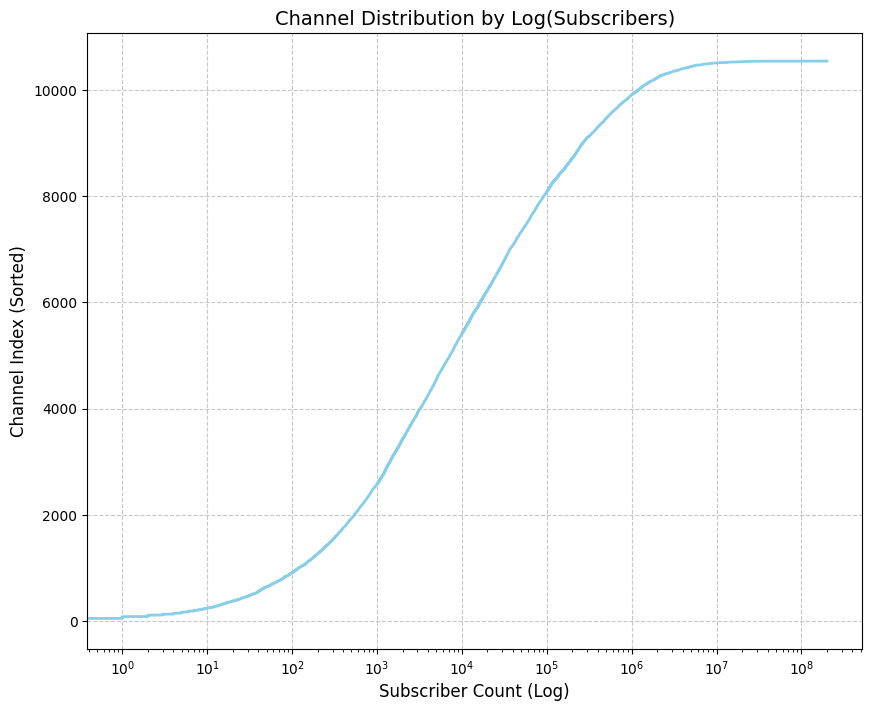

In [44]:
# Plotting the distribution of subscribers to define categories
df_unique_sorted = df.drop_duplicates(subset=["ch_id"]).copy()
df_unique_sorted = df_unique_sorted.sort_values(by="ch_sub")
df_unique_sorted = df_unique_sorted.reset_index(drop=True)

plt.figure(figsize=(10, 8))
plt.plot(df_unique_sorted["ch_sub"], df_unique_sorted.index, color='skyblue', linewidth=2)
plt.xscale('log')
plt.title("Channel Distribution by Log(Subscribers)", fontsize=14)
plt.ylabel("Channel Index (Sorted)", fontsize=12)
plt.xlabel("Subscriber Count (Log)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3.2. Automated Class Selection (Inflection Point Analysis)
Instead of manually defining subscriber thresholds, we use a mathematical approach to identify "inflection points" in the distribution curve. By calculating where the slope of the subscriber growth changes most significantly, we can define natural categories (classes) for our dataset.

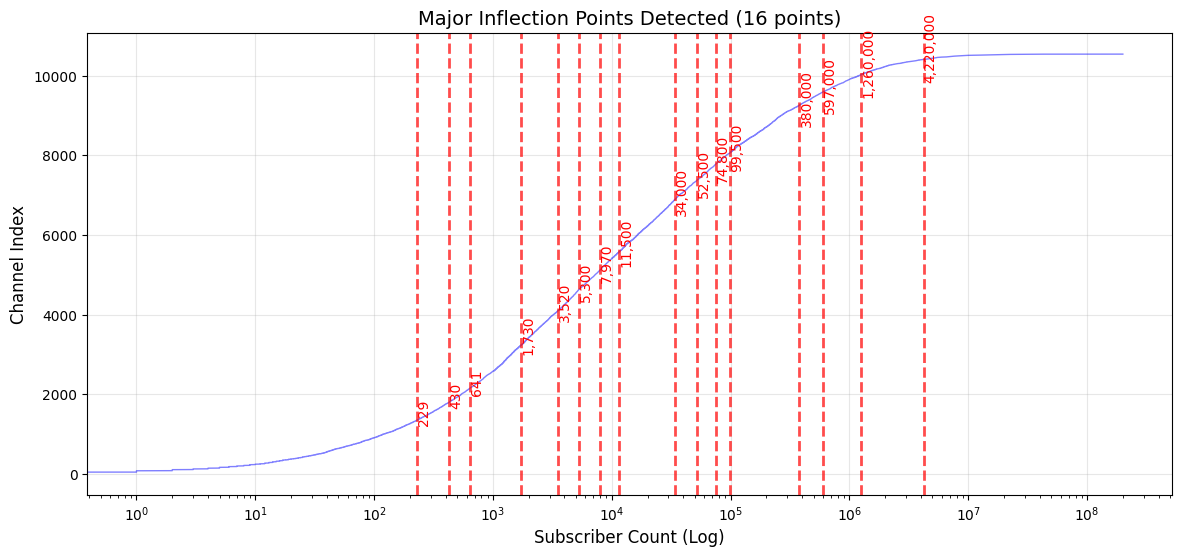


[NOTE] The definition of these classes depends on the size of your dataset.
The more data you collect, the clearer these separation zones become,
leading to more accurate inflection points and better model training.

Final Inflection Points for Binning:
1.          229 subscribers (index:  1,352)
2.          430 subscribers (index:  1,808)
3.          641 subscribers (index:  2,157)
4.        1,730 subscribers (index:  3,241)
5.        3,520 subscribers (index:  4,099)
6.        5,300 subscribers (index:  4,632)
7.        7,970 subscribers (index:  5,126)
8.       11,500 subscribers (index:  5,569)
9.       34,000 subscribers (index:  6,897)
10.       52,500 subscribers (index:  7,387)
11.       74,800 subscribers (index:  7,781)
12.       99,500 subscribers (index:  8,068)
13.      380,000 subscribers (index:  9,262)
14.      597,000 subscribers (index:  9,591)
15.    1,260,000 subscribers (index: 10,028)
16.    4,220,000 subscribers (index: 10,411)


In [45]:
from scipy.cluster.hierarchy import fclusterdata
from scipy.signal import find_peaks

# 1. Data Preparation
# We ensure the unique channel data is sorted by subscriber count
df_unique_sorted = df_unique_sorted.sort_values('ch_sub').reset_index(drop=True)

x = df_unique_sorted['ch_sub'].values
y = df_unique_sorted.index.values
x_log = np.log10(x + 1)

# Eliminate duplicates in log scale to avoid division by zero during slope calculation
indices_uniques = [0]
for i in range(1, len(x_log)):
    if x_log[i] != x_log[i-1]:
        indices_uniques.append(i)

x_log_unique = x_log[indices_uniques]
y_unique = y[indices_uniques]

# 2. Slope and Inflection Calculation
# Calculate the slope (derivative) and smooth it to remove noise
pentes = np.diff(y_unique) / np.diff(x_log_unique)
pentes = np.nan_to_num(pentes, nan=0.0, posinf=0.0, neginf=0.0)

window = max(20, len(pentes) // 20)
pentes_lissees = np.convolve(pentes, np.ones(window)/window, mode='same')

# Calculate the magnitude of slope change (second derivative proxy)
changement_pente = np.abs(np.diff(pentes_lissees))
changement_norm = changement_pente / changement_pente.max()

# 3. Peak Detection
# Identify significant peaks in slope change that represent category boundaries
pics, proprietes = find_peaks(changement_norm, 
                               height=0.3,  # Relative height threshold
                               distance=len(changement_norm)//20)  # Min distance between peaks

# Map peaks back to original data indices
indices_pics = []
for pic in pics:
    if pic < len(indices_uniques) - 1:
        indices_pics.append(indices_uniques[pic + 1])

# 4. Grouping and Filtering
def regrouper_points_proches(indices, distance_min):
    """Groups points that are too close by keeping only one median point per cluster"""
    if len(indices) == 0: return []
    indices_tries = sorted(indices)
    groupes = []
    groupe_actuel = [indices_tries[0]]
    for i in range(1, len(indices_tries)):
        if indices_tries[i] - groupe_actuel[-1] < distance_min:
            groupe_actuel.append(indices_tries[i])
        else:
            groupes.append(int(np.median(groupe_actuel)))
            groupe_actuel = [indices_tries[i]]
    groupes.append(int(np.median(groupe_actuel)))
    return groupes

distance_min = len(x) // 50
indices_regroupes = regrouper_points_proches(indices_pics, distance_min)

# Select the most important inflection points based on magnitude
amplitudes = [changement_norm[pic] for pic in pics]
points_tries = sorted(zip(indices_pics, amplitudes), key=lambda x: x[1], reverse=True)
n_points_desires = 5 
points_importants = [p[0] for p in points_tries[:n_points_desires]]
points_finaux = sorted(set(indices_regroupes + points_importants))

# 5. Final Visualization
plt.figure(figsize=(14, 6))
plt.plot(x, y, 'b-', alpha=0.5, linewidth=1)

for idx in points_finaux:
    plt.axvline(x=x[idx], color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.text(x[idx], y[idx]*0.95, f'{x[idx]:,.0f}', rotation=90, fontsize=10, color='red')

plt.xscale('log')
plt.xlabel("Subscriber Count (Log)", fontsize=12)
plt.ylabel("Channel Index", fontsize=12)
plt.title(f"Major Inflection Points Detected ({len(points_finaux)} points)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()
# Conclusion textuelle après la figure
print("\n[NOTE] The definition of these classes depends on the size of your dataset.")
print("The more data you collect, the clearer these separation zones become,")
print("leading to more accurate inflection points and better model training.")

# Display the values for binning in the next step
print("\nFinal Inflection Points for Binning:")
print("=" * 50)
for i, idx in enumerate(points_finaux):
    print(f"{i+1}. {x[idx]:>12,.0f} subscribers (index: {y[idx]:>6,.0f})")

## 4. Feature Engineering (Data Mining)

### 4.1. Channel Performance Features

In [46]:
# Group data by channel ID to extract aggregate features
ch_df = df.groupby("ch_id").agg(
    sub=("ch_sub", "first"),
    ch_views=("ch_views", "first"),
    ch_videos=("ch_videos", "first"),
    v_views=("v_views", "sum"),
    comments=("comments", "sum"),
    ch_start=("ch_start", "first"),
    crawl=("crawl", "first"),
    v_duration=("v_duration", "sum"),
    last_videos_num=("v_date", "count")
).reset_index()

# Calculate age and engagement metrics
start = pd.to_datetime(ch_df['ch_start'])
end = pd.to_datetime(ch_df['crawl'])
ch_df['age'] = (end.dt.year - start.dt.year)*12*30 + (end.dt.month - start.dt.month)*30 + (end.dt.day - start.dt.day)

ch_df['views_per_video'] = ch_df['ch_views'] / (ch_df['ch_videos'] + 1)
ch_df["ch_v_per_month"] = 30 * (ch_df['ch_videos'] / (ch_df['age'] + 1))
ch_df["engagement"] = ch_df["comments"] / (ch_df['ch_videos'] + 1)



### 4.2. Regularity and Upload Frequency

In [47]:
# Calculate days between uploads (delta_days)
df['v_date'] = pd.to_datetime(df["v_date"])
vd_df = df.sort_values(["ch_id", "v_date"])
vd_df["delta_days"] = vd_df.groupby("ch_id")["v_date"].diff().dt.days

# Aggregate upload consistency stats
stats = vd_df.dropna(subset=["delta_days"]).groupby("ch_id").agg(
    mean=("delta_days", "mean"),
    std=("delta_days", "std"),
    v_mean=("v_views", "mean"),
    v_duration_mean=("v_duration", "mean"),
    total_v_duration=("v_duration", "sum")
).reset_index()

# Calculate Irregularity Coefficient
stats["irregularity_cv"] = stats.apply(
    lambda row: row["std"] / row["mean"] if row["mean"] else 0, axis=1
)

# Merge features into the main feature set
df_features = ch_df.merge(stats, on="ch_id", how="left").fillna(0)
df_features.isnull().sum()

ch_id               0
sub                 0
ch_views            0
ch_videos           0
v_views             0
comments            0
ch_start            0
crawl               0
v_duration          0
last_videos_num     0
age                 0
views_per_video     0
ch_v_per_month      0
engagement          0
mean                0
std                 0
v_mean              0
v_duration_mean     0
total_v_duration    0
irregularity_cv     0
dtype: int64

## 5. Preparation for Machine Learning

### 5.1. Log Transformation & Normalization

To reduce the impact of outliers and normalize skewed distributions, we apply a Log transformation (log(1+x)) to numerical columns.

In [48]:

# Apply Log1p transformation to skewed numerical features
cols_to_log = [
    "engagement",
    "ch_views",
    "v_views",
    "total_v_duration",
    "comments",
    "views_per_video",
    "ch_videos",
    "v_duration",
    "mean",
    "std",
    "irregularity_cv",
    "v_mean", #desactiver c'est mieu
    "v_duration_mean",
    "age",
    

]
for col in cols_to_log:
    df_features[col] = df_features[col].clip(lower=0).fillna(0)
    df_features[col] = np.log1p(df_features[col])

# Create dummy variables for the starting year
#df_features["year"] = pd.to_datetime(df_features["ch_start"]).dt.year
#df_features = pd.get_dummies(df_features, columns=["year"])

### 5.2. Categorization and Export
Finally, we categorize channels into classes based on subscriber thresholds and export the cleaned dataset for Machine Learning modeling.

In [49]:
# Categorize channels into classes based on subscriber inflection points
bins=[0,100,1000,20000,200000,2000000,np.inf]
labels = [0, 1, 2, 3, 4, 5]
df_features["class"] = pd.cut(df_features["sub"], bins=bins, labels=labels, include_lowest=True)

# Final export
df_features.drop(columns=["ch_id", "ch_start", "crawl", "sub"], inplace=True)
df_features.to_csv("ML_data.csv", index=False)
print("Data Wrangling complete. Dataset ready for Machine Learning.")

Data Wrangling complete. Dataset ready for Machine Learning.
